# Retinal Vessel Segmentation — Domain Shift & Test-Time Adaptation

This notebook walks through the full experiment:
1. Data exploration (DRIVE, STARE, CHASE)
2. Training the U-Net with rotation head
3. Baseline evaluation on out-of-domain data
4. Test-Time Adaptation (TTT) and comparison
5. Visual results

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import torch
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

## 1. Data Exploration — Visualize Domain Shift

In [ ]:
def show_sample(image_dir, mask_dir, title, n=3):
    img_paths  = sorted([os.path.join(image_dir, f) for f in os.listdir(image_dir)])[:n]
    mask_paths = sorted([os.path.join(mask_dir, f)  for f in os.listdir(mask_dir)])[:n]
    fig, axes = plt.subplots(2, n, figsize=(5*n, 4))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    for i in range(n):
        axes[0, i].imshow(Image.open(img_paths[i]).convert('RGB'))
        axes[0, i].set_title('Image'); axes[0, i].axis('off')
        axes[1, i].imshow(Image.open(mask_paths[i]).convert('L'), cmap='gray')
        axes[1, i].set_title('Mask');  axes[1, i].axis('off')
    plt.tight_layout()
    plt.show()

show_sample('../data/DRIVE/images', '../data/DRIVE/masks',  'DRIVE (train domain)')
show_sample('../data/STARE/images', '../data/STARE/masks',  'STARE (target domain)')
show_sample('../data/CHASE/images', '../data/CHASE/masks',  'CHASE (target domain)')

## 2. Model Architecture

In [2]:
from models.unet import UNetWithRotationHead

model = UNetWithRotationHead(n_channels=3, n_classes=1)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total_params:,}')

# Test forward pass
dummy = torch.randn(1, 3, 512, 512)
seg, rot = model(dummy, return_rotation_logits=True)
print(f'Segmentation output shape: {seg.shape}')   # [1, 1, 512, 512]
print(f'Rotation output shape:     {rot.shape}')   # [1, 4]

## 3. Training

In [ ]:
# Train the U-Net with rotation head on DRIVE.
# Equivalent CLI: python training/train.py --data_root data/DRIVE --epochs 50 --batch_size 4
import subprocess
result = subprocess.run(
    ['python', '../training/train.py',
     '--data_root', '../data/DRIVE',
     '--epochs', '50',
     '--batch_size', '4'],
    capture_output=True, text=True
)
print(result.stdout[-3000:])
if result.stderr: print('STDERR:', result.stderr[-1000:])

## 4. Baseline vs TTT Evaluation

In [4]:
from models.unet import UNetWithRotationHead
from training.dataset import get_test_loader
from ttt.adapt import run_baseline_inference, run_ttt_inference
from evaluation.metrics import evaluate, print_metrics

# Load best checkpoint
model = UNetWithRotationHead(n_channels=3, n_classes=1)
ckpt  = torch.load('../checkpoints/best_model.pth', map_location=device)
model.load_state_dict(ckpt['model_state'])
model.to(device)
print(f"Loaded model — val_dice on DRIVE: {ckpt.get('val_dice', 'N/A')}")

In [ ]:
# Evaluate on STARE
stare_loader = get_test_loader('../data/STARE/images', '../data/STARE/masks', img_size=512)

print('Running baseline...')
base_preds, base_masks = [], []
for p, m in run_baseline_inference(model, stare_loader, device):
    base_preds.append(p.cpu()); base_masks.append(m.cpu())
baseline = evaluate(base_preds, base_masks)
print_metrics(baseline, 'Baseline — STARE')

print('Running TTT (10 steps)...')
ttt_preds, ttt_masks = [], []
for p, m in run_ttt_inference(model, stare_loader, device, n_steps=10, lr=1e-5):
    ttt_preds.append(p.cpu()); ttt_masks.append(m.cpu())
ttt = evaluate(ttt_preds, ttt_masks)
print_metrics(ttt, 'After TTT — STARE')

## 5. Results Comparison Chart

In [ ]:
metrics_keys = ['dice', 'iou', 'sensitivity', 'specificity']
baseline_vals = [baseline[k] for k in metrics_keys]
ttt_vals      = [ttt[k]      for k in metrics_keys]

x = np.arange(len(metrics_keys))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline', color='steelblue')
bars2 = ax.bar(x + width/2, ttt_vals,      width, label='TTT',      color='coral')

ax.set_ylabel('Score')
ax.set_title('Baseline vs TTT on STARE (domain shift)')
ax.set_xticks(x)
ax.set_xticklabels(metrics_keys)
ax.set_ylim(0, 1)
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3)
ax.bar_label(bars2, fmt='%.3f', padding=3)
plt.tight_layout()
plt.savefig('results_comparison.png', dpi=150)
plt.show()

## 6. Visual Prediction Comparison

In [5]:
import torch
from training.dataset import RetinalDataset
from ttt.adapt import test_time_adapt

ds = RetinalDataset('../data/STARE/images', '../data/STARE/masks', img_size=512)

idx = 0
img, mask = ds[idx]
img_batch = img.unsqueeze(0).to(device)

# Baseline prediction
model.eval()
with torch.no_grad():
    base_pred = (torch.sigmoid(model(img_batch)) > 0.5).float().squeeze().cpu().numpy()

# TTT prediction
ttt_logits = test_time_adapt(model, img_batch, n_steps=10, lr=1e-5)
ttt_pred   = (torch.sigmoid(ttt_logits) > 0.5).float().squeeze().cpu().numpy()

gt_mask = mask.squeeze().numpy()
orig_img = img.permute(1,2,0).numpy()

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(orig_img);             axes[0].set_title('Input Image');       axes[0].axis('off')
axes[1].imshow(gt_mask,  cmap='gray'); axes[1].set_title('Ground Truth');      axes[1].axis('off')
axes[2].imshow(base_pred,cmap='gray'); axes[2].set_title('Baseline Pred');     axes[2].axis('off')
axes[3].imshow(ttt_pred, cmap='gray'); axes[3].set_title('TTT Pred');          axes[3].axis('off')
plt.suptitle('Domain Shift: DRIVE-trained model on STARE image', fontsize=13)
plt.tight_layout()
plt.savefig('visual_comparison.png', dpi=150)
plt.show()

---

# 7. Final Results (Full Run on Google Colab — Tesla T4 GPU)

The cells above show the pipeline running locally on a small scale. The **complete**
experiments — full evaluation on STARE, CHASE and HRF, the TTA-vs-TTT ablation, the
domain-gap analysis and the CLAHE intensity-correction study — were executed on a
Google Colab T4 GPU. The resulting figures are embedded below so they are visible
without re-running the heavy computation.

In [6]:
import os
from IPython.display import Image, display, Markdown

# Figures produced by the full Colab run (saved under report/figures/)
FIG_DIR = os.path.join('..', 'report', 'figures')

def show_figure(filename, caption):
    """Display a saved result figure with a caption."""
    path = os.path.join(FIG_DIR, filename)
    display(Markdown(f'**{caption}**'))
    display(Image(filename=path))

## 7.1 Domain-gap analysis — why CHASE collapses

CHASE images are roughly 40% darker than the DRIVE training distribution. This
intensity shift — not vessel morphology — is the dominant cause of the failure.

**Intensity statistics per dataset — CHASE is markedly darker than DRIVE.**

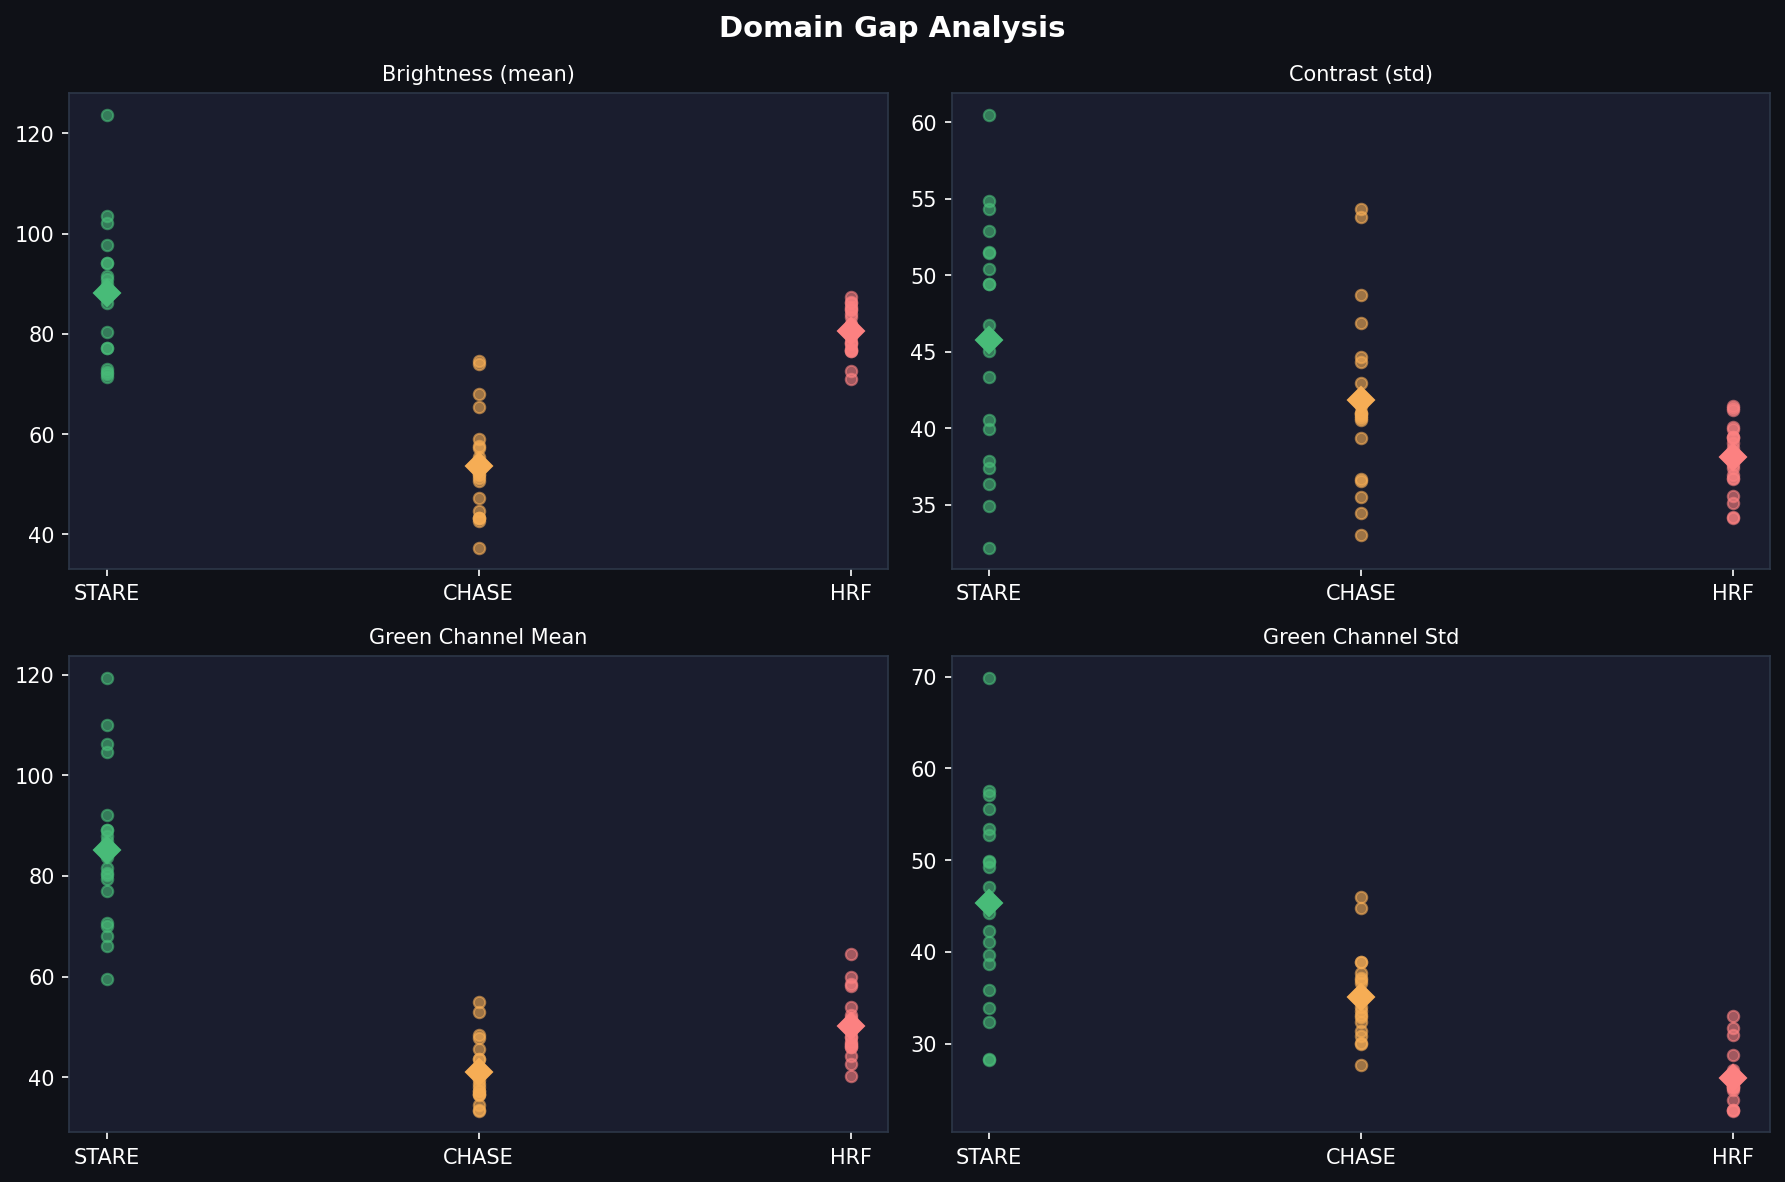

In [7]:
show_figure('domain_analysis.png',
            'Intensity statistics per dataset — CHASE is markedly darker than DRIVE.')

## 7.2 Baseline vs TTT across all datasets

Rotation-based TTT yields only marginal Dice gains (+0.002 to +0.005).

**Baseline vs TTT Dice across STARE, CHASE and HRF.**

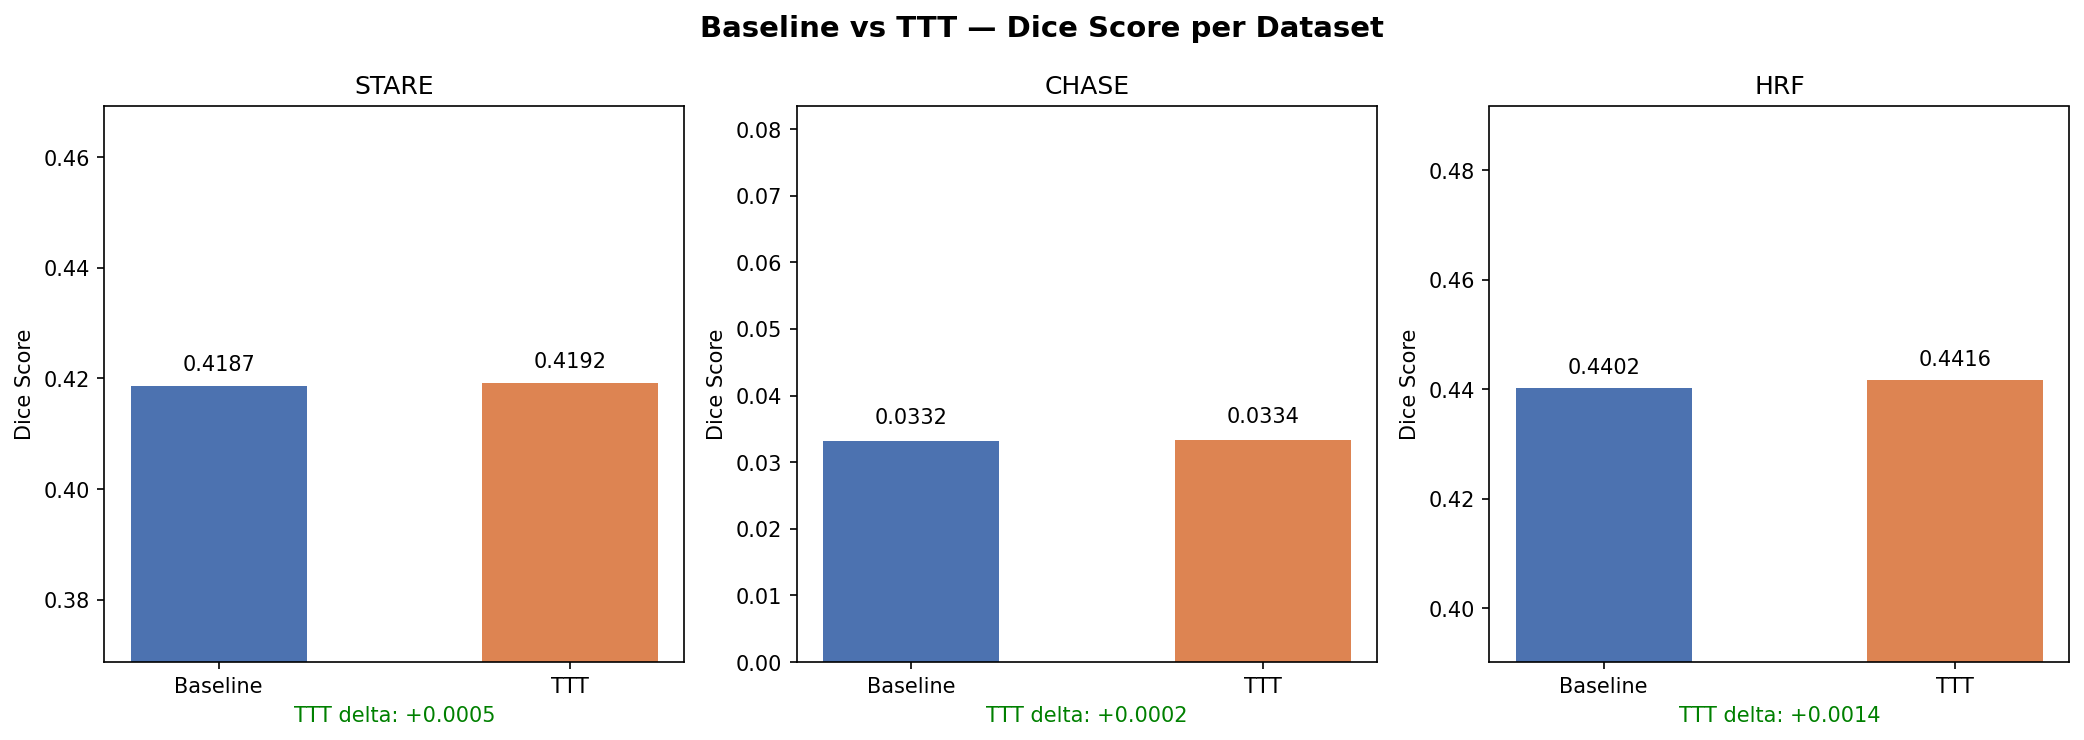

**All metrics (Dice, IoU, sensitivity, specificity) compared.**

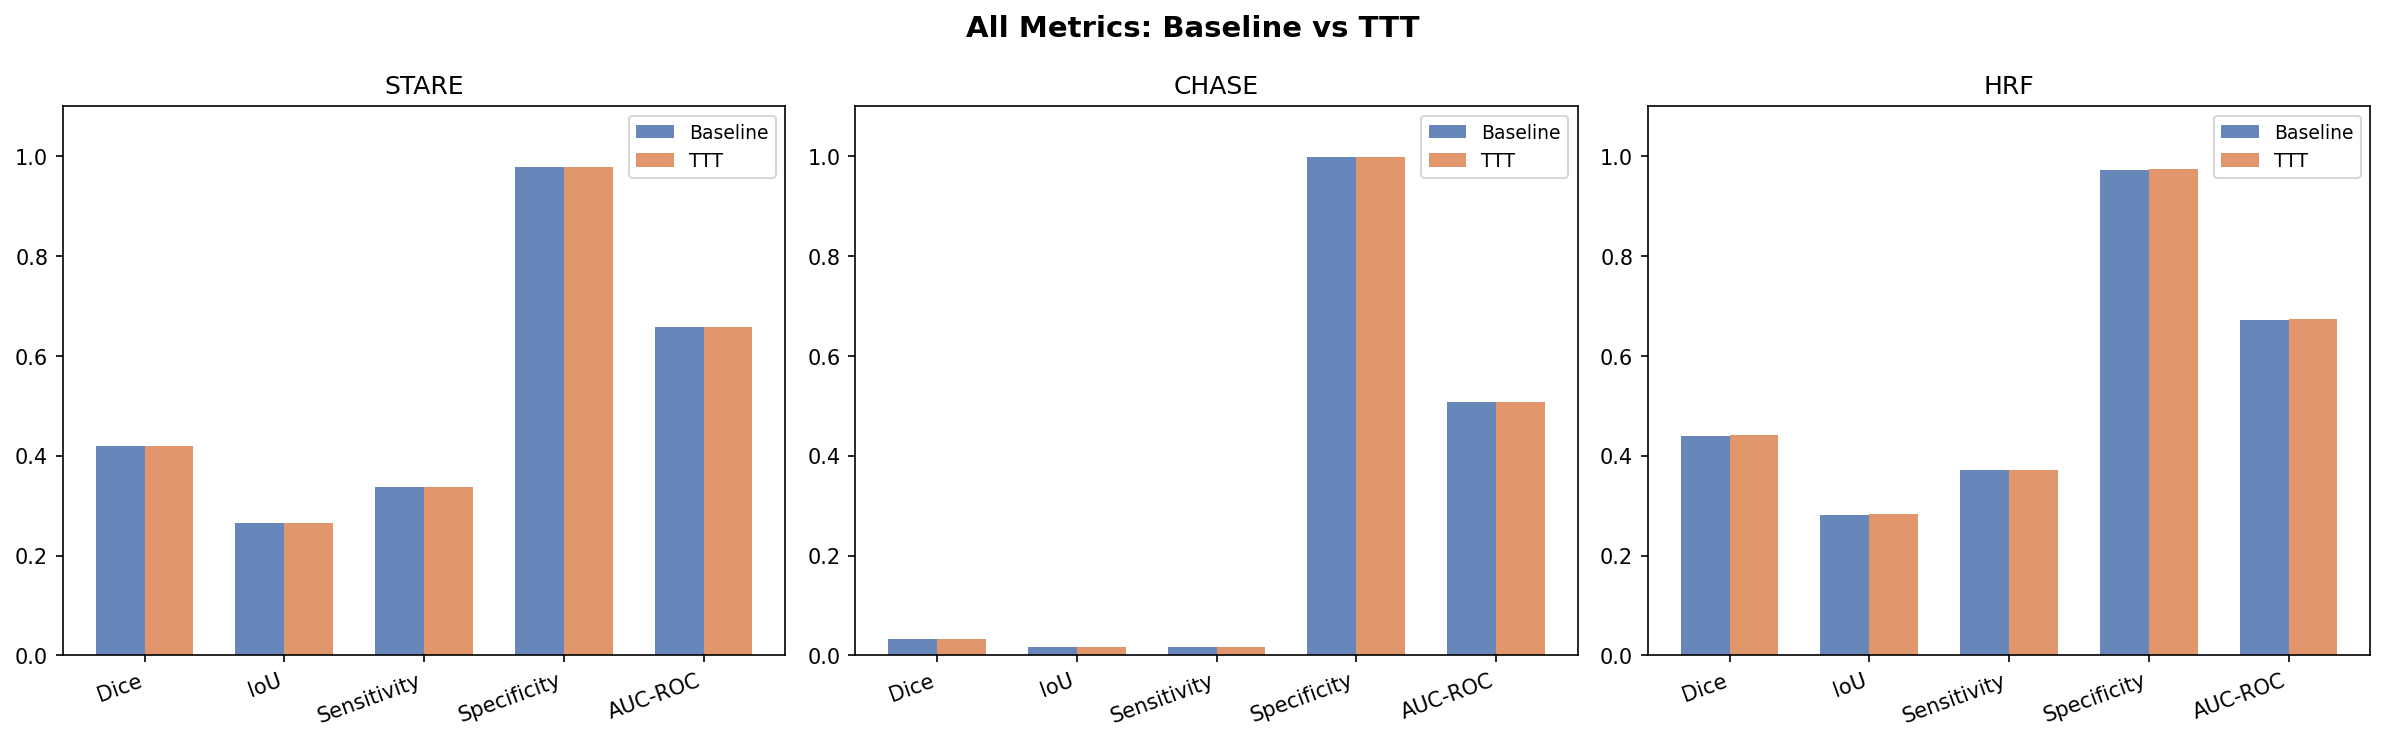

In [8]:
show_figure('dice_comparison.png', 'Baseline vs TTT Dice across STARE, CHASE and HRF.')
show_figure('all_metrics_comparison.png', 'All metrics (Dice, IoU, sensitivity, specificity) compared.')

## 7.3 Ablation — TTA vs TTT and adaptation scope

Simple TTA beats TTT on STARE/HRF but harms CHASE. Adapting BatchNorm, the encoder
or the full network gives essentially identical results.

**Ablation of adaptation strategies and parameter scope.**

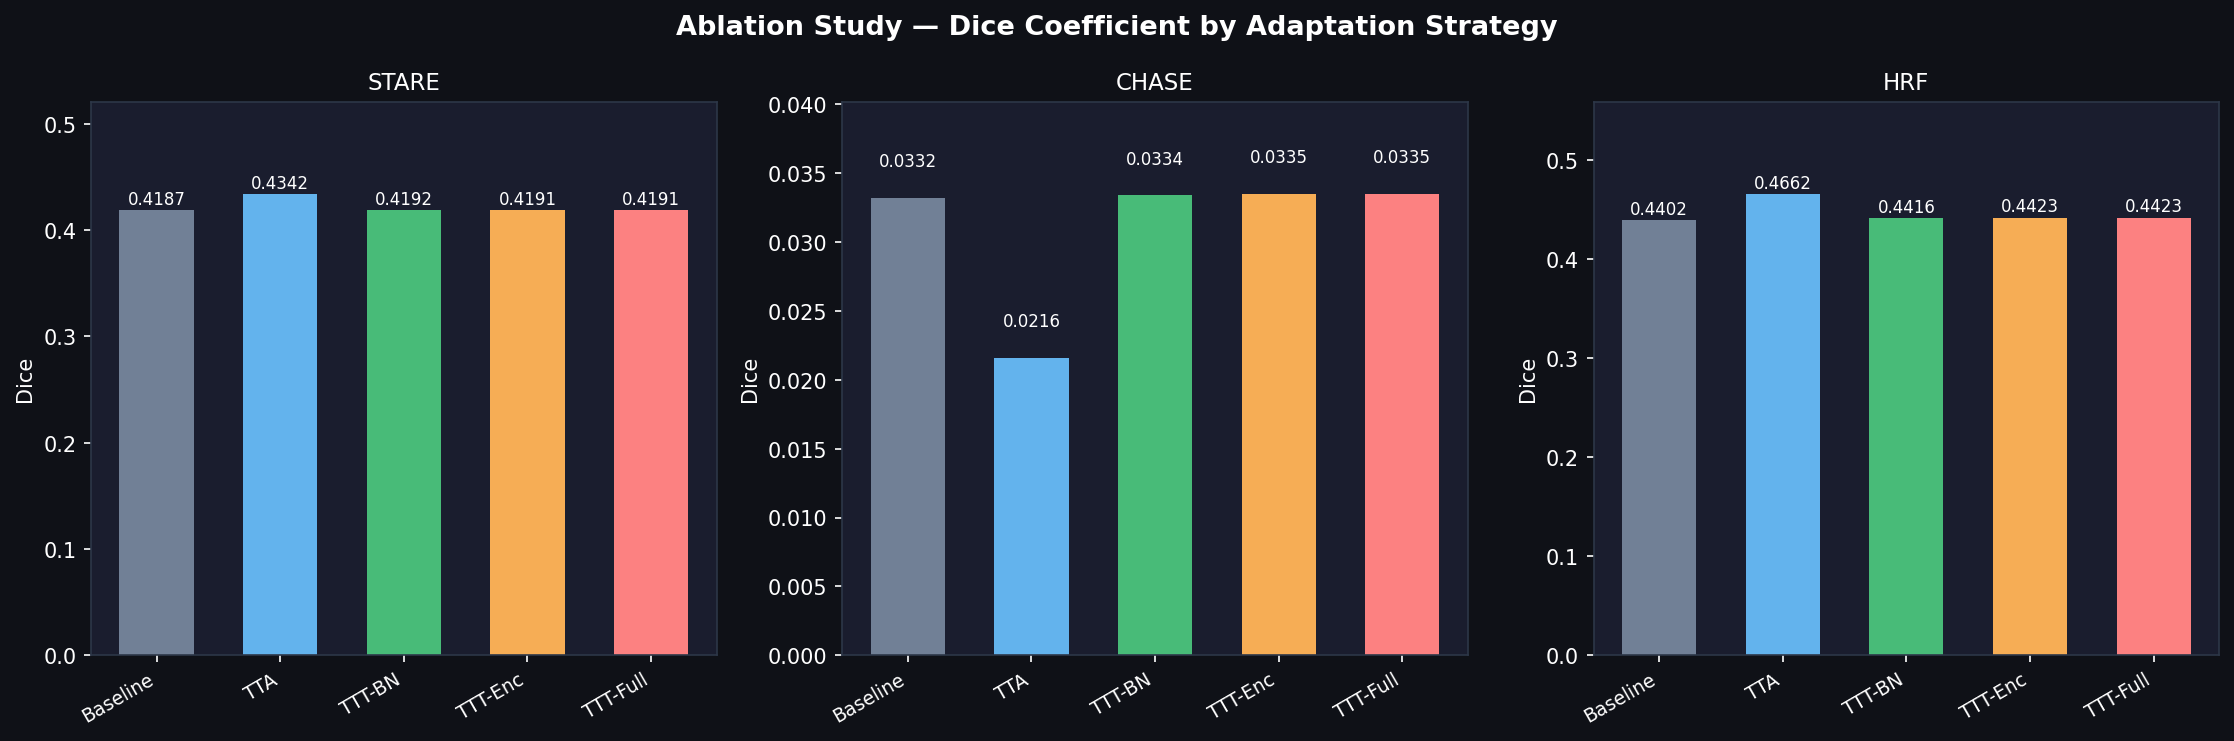

In [9]:
show_figure('ablation_study.png', 'Ablation of adaptation strategies and parameter scope.')

## 7.4 Intensity correction (CLAHE) — the key result

Applying CLAHE before inference lifts CHASE Dice from ~0.033 to ~0.357 — roughly a
**10× improvement** from a single preprocessing step, confirming the collapse is an
intensity problem rather than a vessel-structure one.

**CLAHE intensity correction — the decisive experiment (CHASE ~10x Dice gain).**

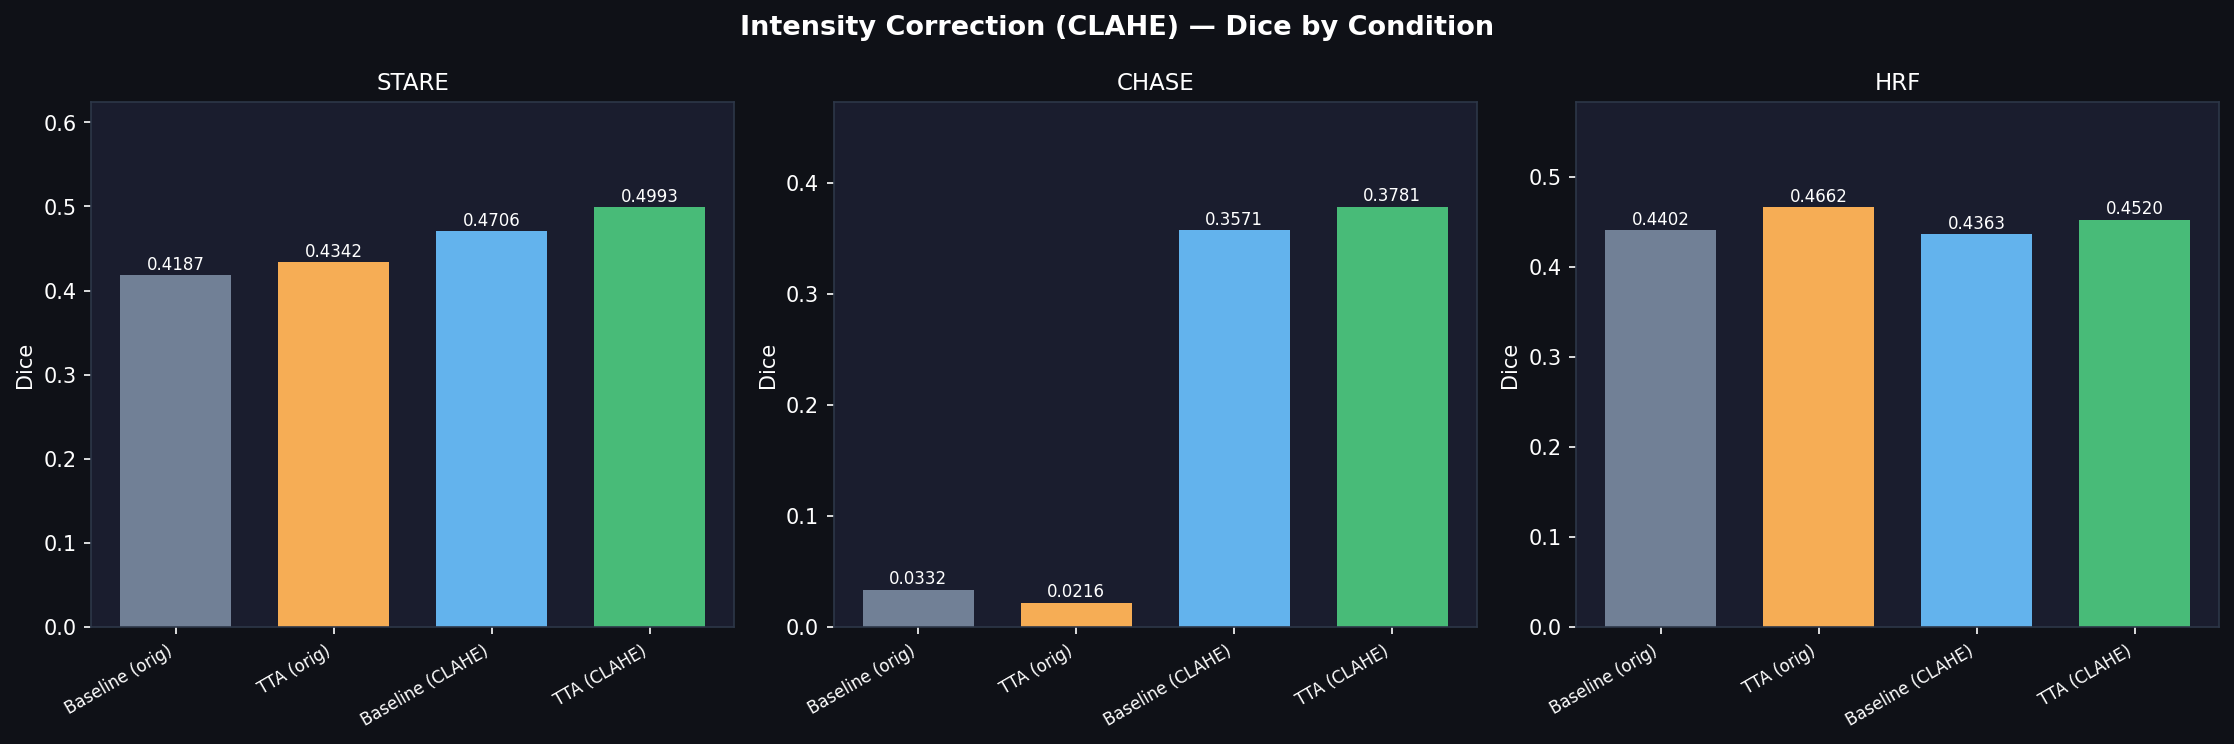

In [10]:
show_figure('intensity_correction.png',
            'CLAHE intensity correction — the decisive experiment (CHASE ~10x Dice gain).')

## 7.5 Qualitative predictions and ROC curves

**ROC curves across datasets.**

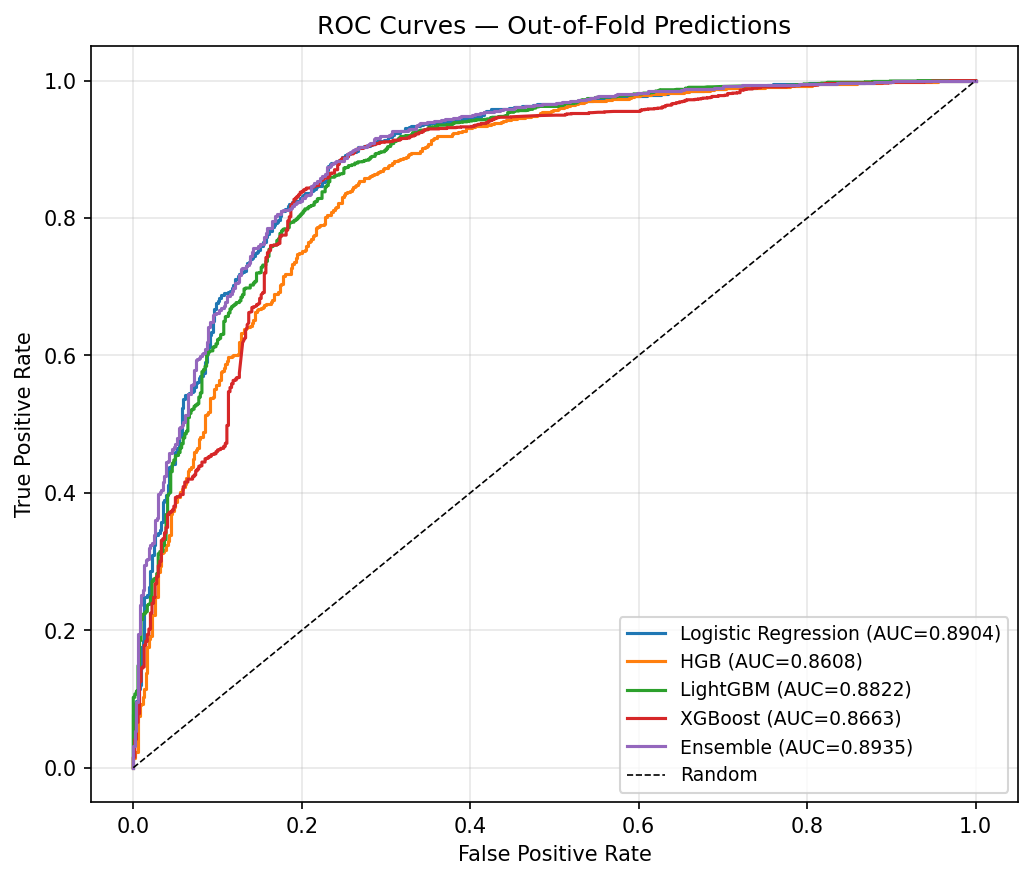

**STARE qualitative predictions (input / GT / baseline / TTT).**

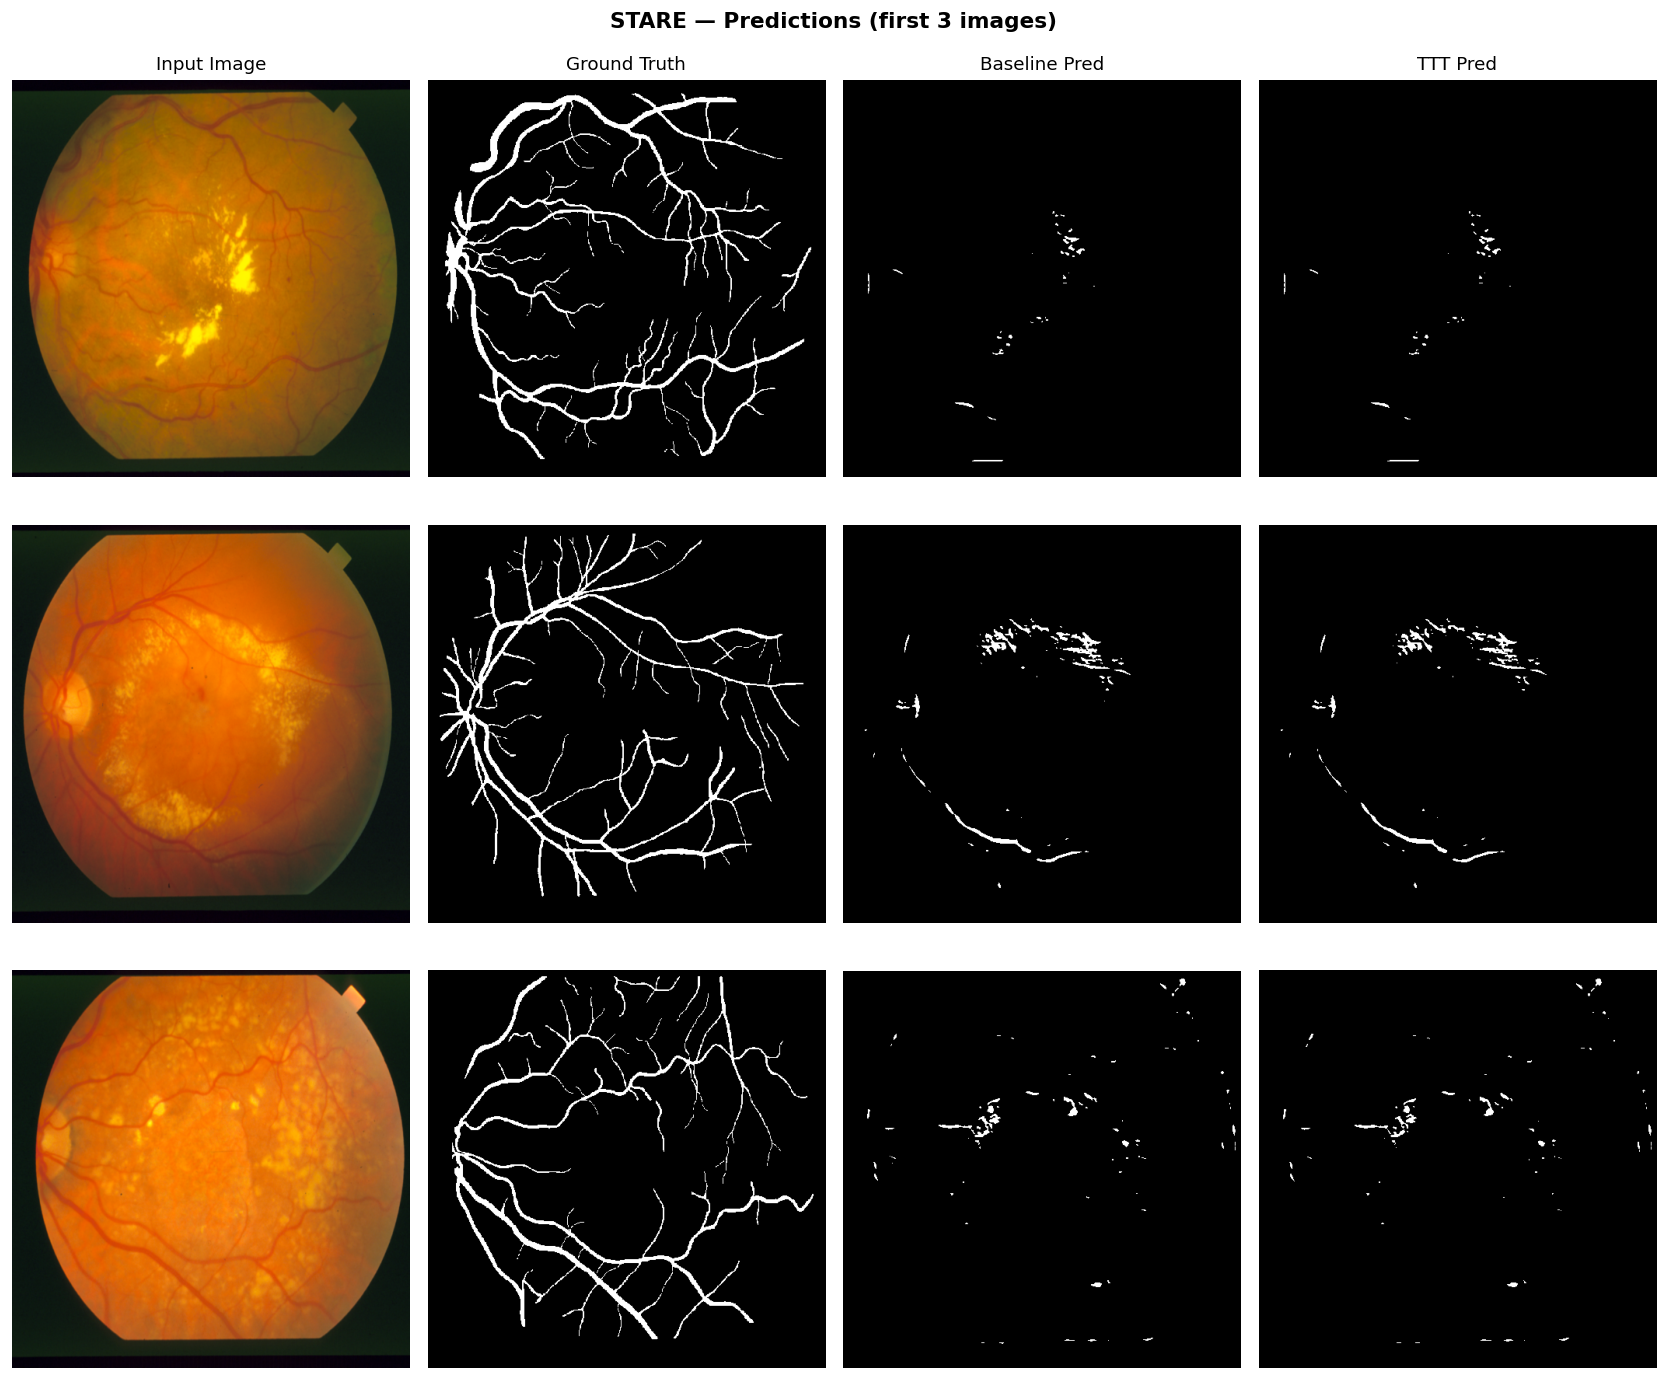

**CHASE qualitative predictions — near-total collapse on dark inputs.**

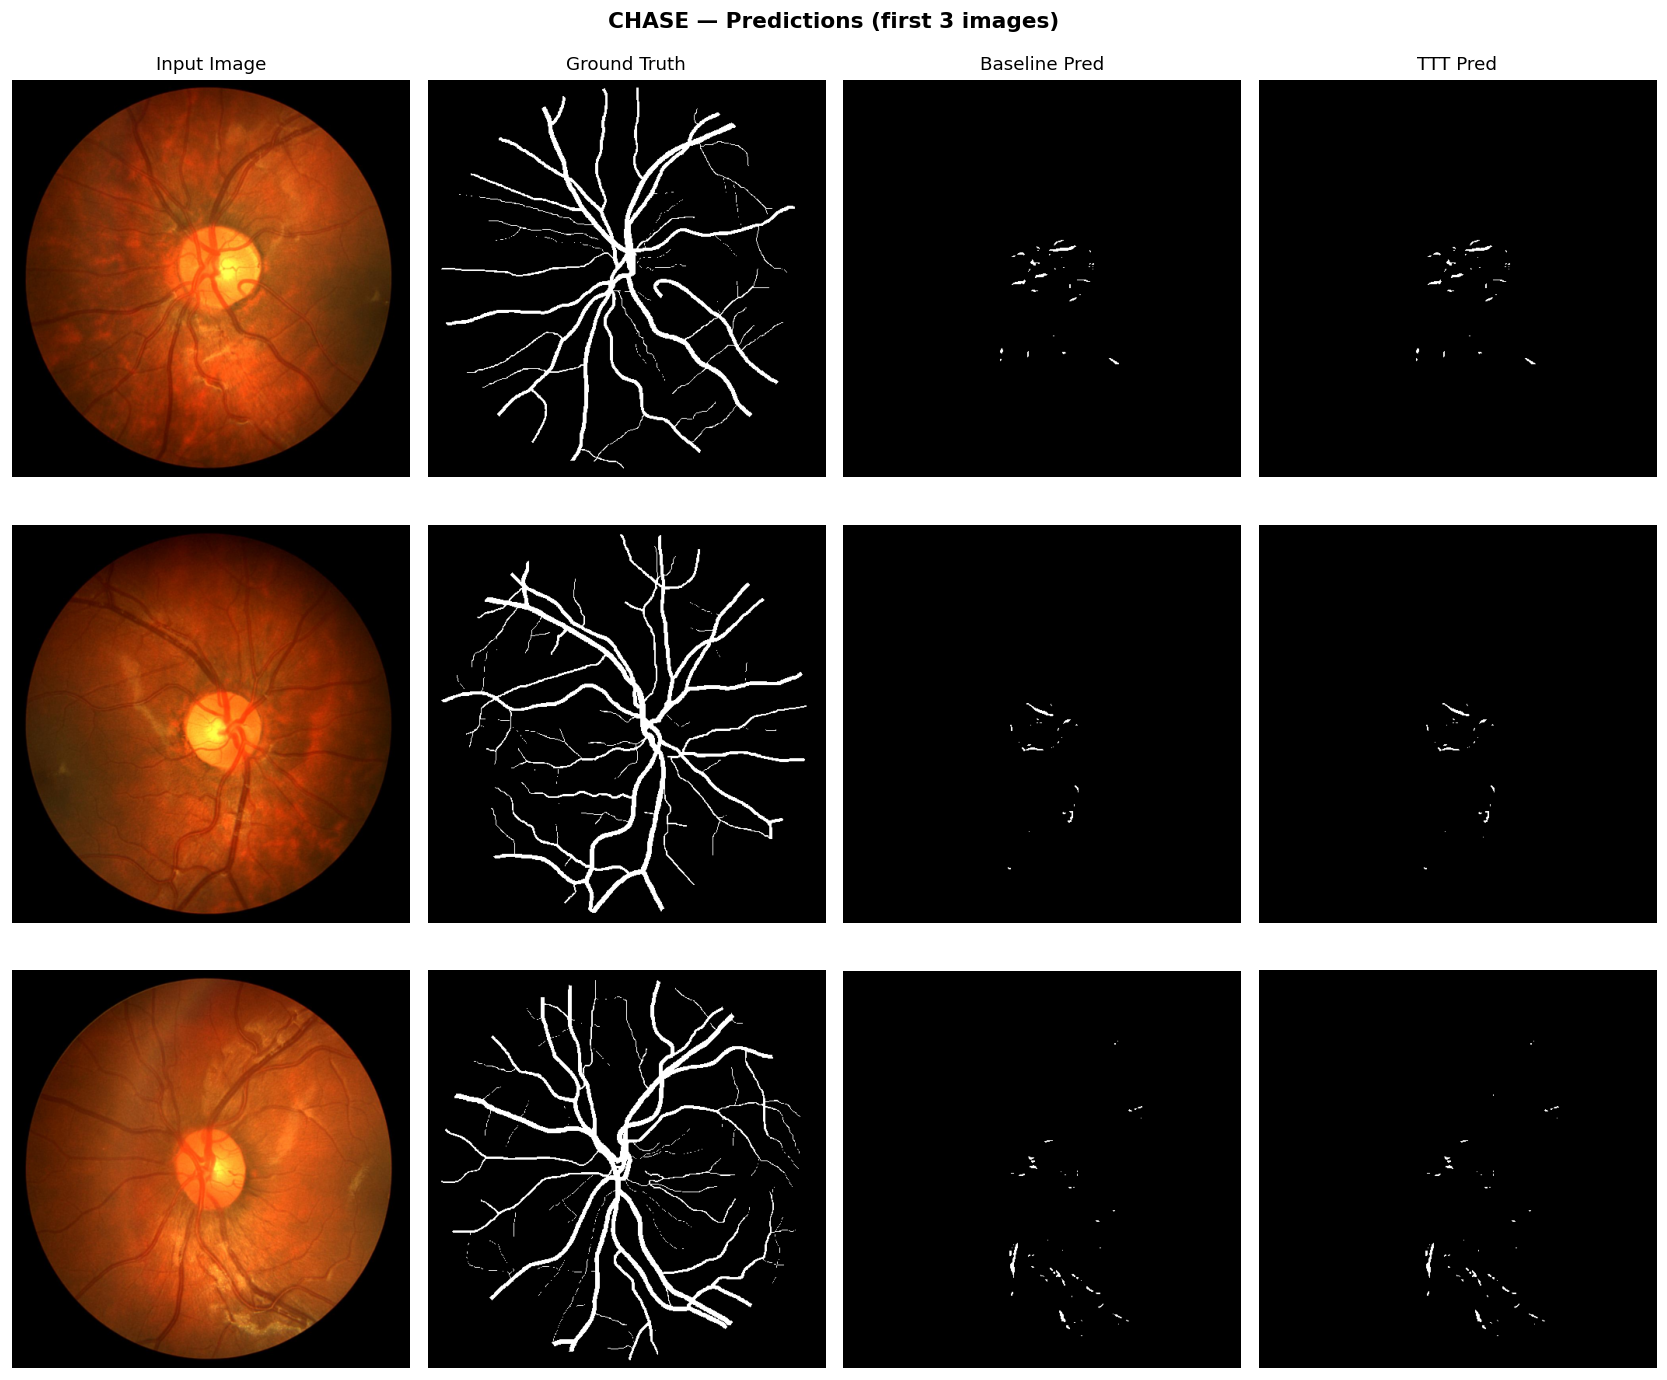

**HRF qualitative predictions.**

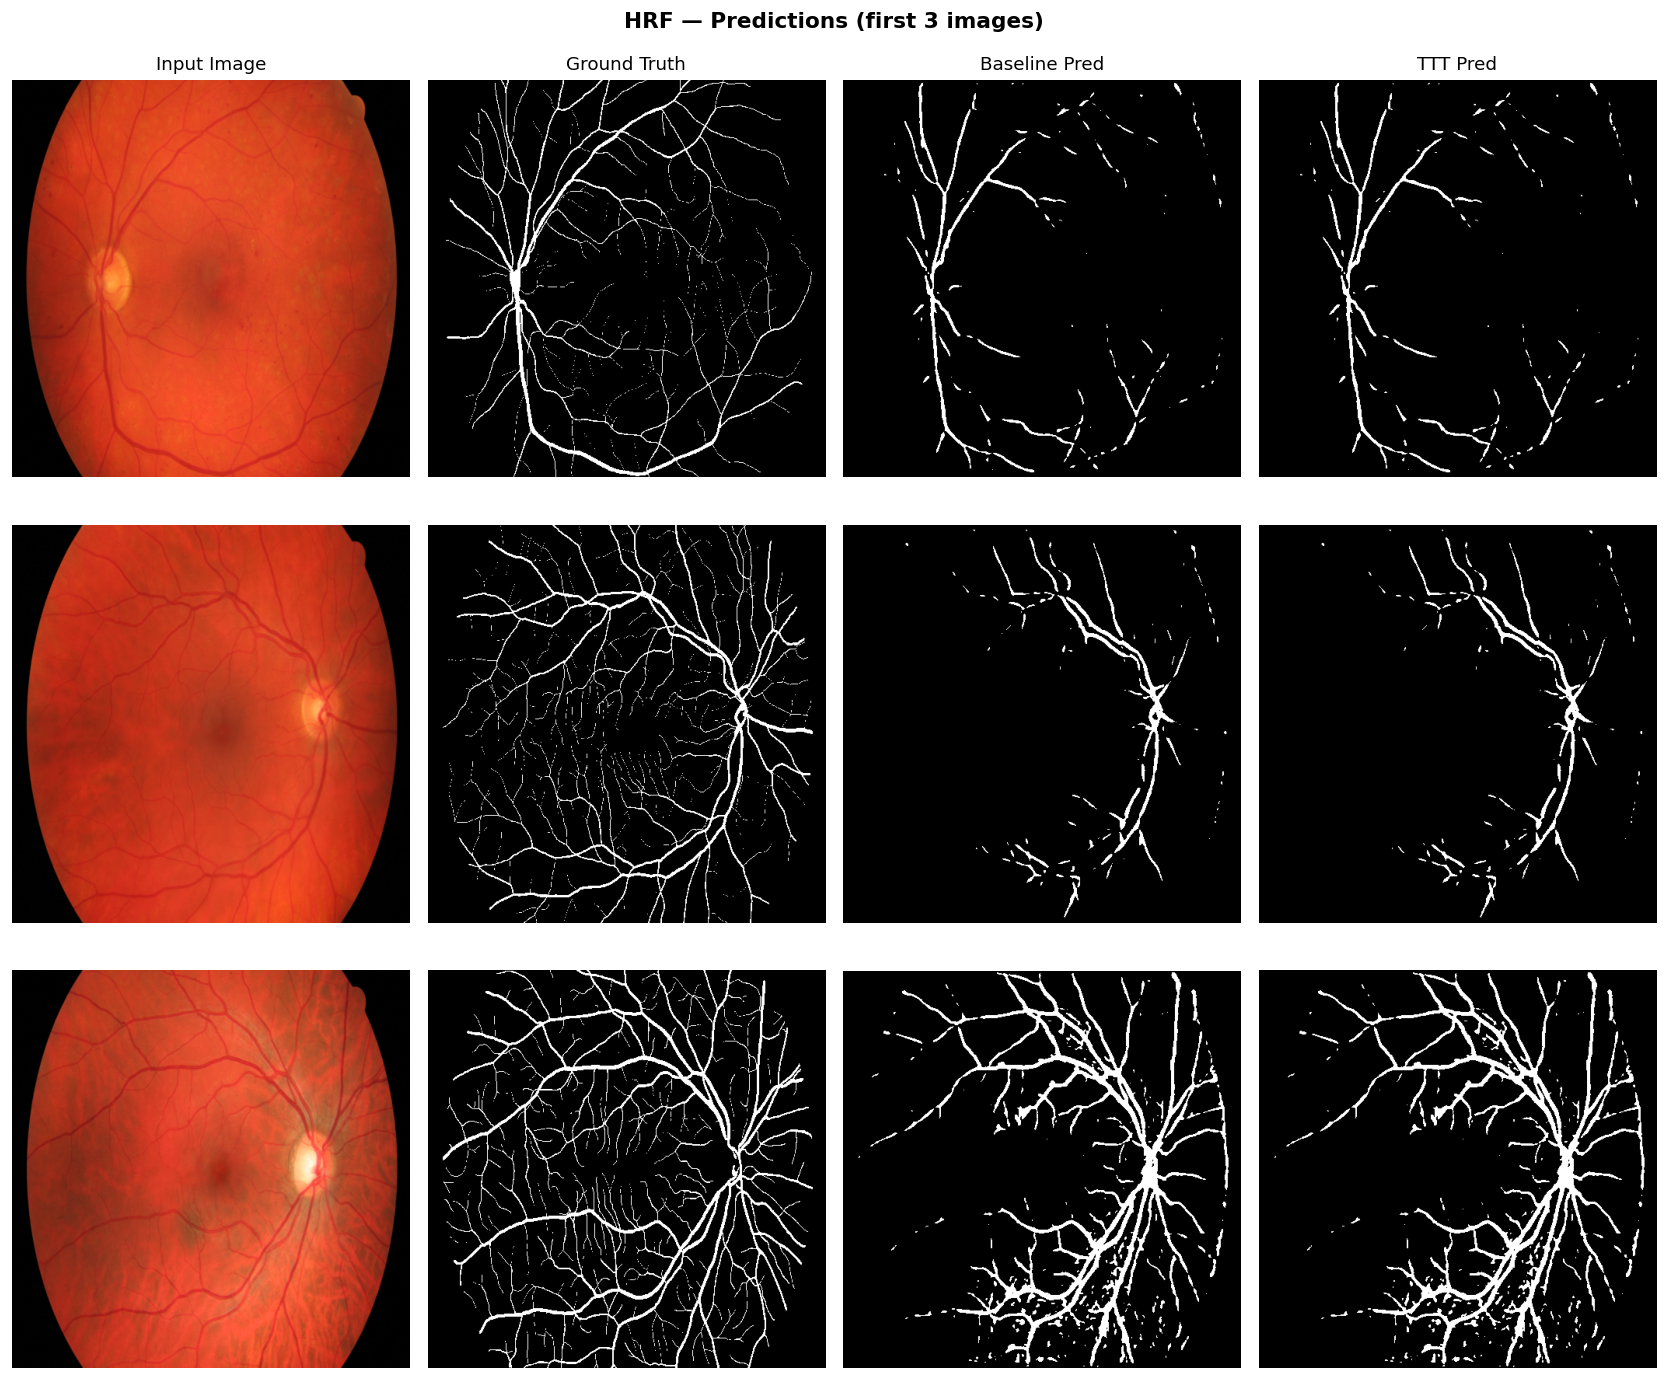

In [11]:
show_figure('roc_curves.png', 'ROC curves across datasets.')
show_figure('stare_predictions.png', 'STARE qualitative predictions (input / GT / baseline / TTT).')
show_figure('chase_predictions.png', 'CHASE qualitative predictions — near-total collapse on dark inputs.')
show_figure('hrf_predictions.png', 'HRF qualitative predictions.')